In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [9]:
ave_spend = 15.5   #average spend per customer
fixed_base_rev = 120   # fixed base revenue

df = pd.DataFrame({
    "day":       ["Monday", "Tuesday"],
    "customers": [40,        60],         # x – number of customers
    "actual_revenue":    [750,       1050],        # y – real observed revenue ($)
})

In [10]:
df['predicted'] = ave_spend * df['customers'] + fixed_base_rev 
df['residual'] = df['actual_revenue'] - df['predicted']
df

,day,customers,actual_revenue,predicted,residual
0,Monday,40,750,740.0,10.0
1,Tuesday,60,1050,1050.0,0.0


In [11]:
print(f'Predicted revenue for Monday = {df["predicted"][0]:.2f}')
print(f'Predicted revenue for Tuesday = {df["predicted"][1]:.2f}')
print(f'Residual for Monday = {df["residual"][0]:.2f}')
print(f'Residual for Tuesday = {df["residual"][1]:.2f}')

Predicted revenue for Monday = 740.00
Predicted revenue for Tuesday = 1050.00
Residual for Monday = 10.00
Residual for Tuesday = 0.00


In [12]:
saturday_customers = 100
saturday_predicted = ave_spend * saturday_customers + fixed_base_rev 

In [13]:
print(f"\n  Equation: y = {ave_spend}x + {fixed_base_rev}")
print(f"    customers          = {saturday_customers}")
print(f"    predicted revenue  = {ave_spend} × {saturday_customers} + {fixed_base_rev} = ${saturday_predicted:,.1f}")
print()


  Equation: y = 15.5x + 120
    customers          = 100
    predicted revenue  = 15.5 × 100 + 120 = $1,670.0



C:\Users\Admin\AppData\Local\Temp\ipykernel_13464\3902943925.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


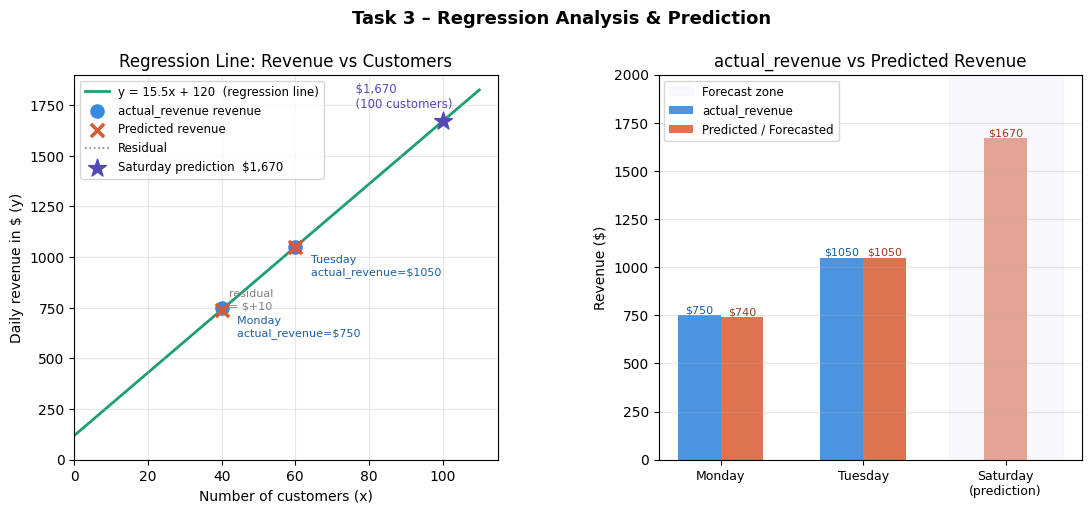

In [14]:
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

# ── Left panel: main regression chart ──
ax1 = fig.add_subplot(gs[0])

# Draw the full regression line from x=0 to x=110
x_line = np.linspace(0, 110, 300)  # 300 smooth points
y_line = ave_spend * x_line + fixed_base_rev

ax1.plot(
    x_line, y_line,
    color="#1D9E75",    # green line
    lw=2,
    label="y = 15.5x + 120  (regression line)",
    zorder=1
)

# Plot actual_revenue revenue points (blue circles)
ax1.scatter(
    df["customers"], df["actual_revenue"],
    color="#378ADD", s=90, zorder=5,
    label="actual_revenue revenue"
)

# Plot predicted revenue points (orange X marks)
ax1.scatter(
    df["customers"], df["predicted"],
    color="#D85A30", s=90, zorder=5,
    marker="x", linewidths=2.5,
    label="Predicted revenue"
)

# Draw vertical residual lines (the gap = residual)
for _, row in df.iterrows():
    if row["residual"] != 0:
        ax1.vlines(
            x=row["customers"],
            ymin=min(row["predicted"], row["actual_revenue"]),
            ymax=max(row["predicted"], row["actual_revenue"]),
            color="gray", lw=1.2, ls="dotted",
            label="Residual" if _ == 0 else "_nolegend_"
        )
        ax1.annotate(
            f"  residual\n  = ${row['residual']:+.0f}",
            xy=(row["customers"], (row["predicted"] + row["actual_revenue"]) / 2),
            fontsize=8, color="gray"
        )

# Plot Saturday as a purple star
ax1.scatter(
    [saturday_customers], [saturday_predicted],
    color="#534AB7", s=180, zorder=6,
    marker="*",
    label=f"Saturday prediction  ${saturday_predicted:,.0f}"
)
ax1.annotate(
    f"  $1,670\n  (100 customers)",
    xy=(saturday_customers, saturday_predicted),
    xytext=(-68, 10),
    textcoords="offset points",
    fontsize=8.5, color="#534AB7"
)

# Annotate Monday and Tuesday dots
for _, row in df.iterrows():
    ax1.annotate(
        f"  {row['day']}\n  actual_revenue=${int(row['actual_revenue'])}",
        xy=(row["customers"], row["actual_revenue"]),
        xytext=(6, -20),
        textcoords="offset points",
        fontsize=8, color="#185FA5"
    )

ax1.set_xlabel("Number of customers (x)")
ax1.set_ylabel("Daily revenue in $ (y)")
ax1.set_title("Regression Line: Revenue vs Customers")
ax1.legend(fontsize=8.5, loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 115)
ax1.set_ylim(0, 1900)

# ── Right panel: residual bar chart ──
ax2 = fig.add_subplot(gs[1])

days      = df["day"].tolist() + ["Saturday\n(prediction)"]
actual_revenues   = df["actual_revenue"].tolist() + [None]
predicteds= df["predicted"].tolist() + [saturday_predicted]

bar_w = 0.3
x_pos = range(len(days))

# actual_revenue bars (blue) – only for Mon & Tue
ax2.bar(
    [p - bar_w/2 for p in x_pos[:2]],
    df["actual_revenue"], width=bar_w,
    color="#378ADD", label="actual_revenue", alpha=0.9
)

ax2.bar(
    [p + bar_w/2 for p in x_pos[:2]] + [x_pos[2]],
    df["predicted"].tolist() + [saturday_predicted],
    width=bar_w,
    color="#D85A30",
    label="Predicted / Forecasted", alpha=0.85
)
for i, (act, pred) in enumerate(zip(df["actual_revenue"], df["predicted"])):
    ax2.text(i - bar_w/2, act + 10, f"${int(act)}", ha="center", fontsize=8, color="#185FA5")
    ax2.text(i + bar_w/2, pred + 10, f"${int(pred)}", ha="center", fontsize=8, color="#993C1D")

ax2.text(2, saturday_predicted + 10, f"${int(saturday_predicted)}", ha="center", fontsize=8, color="#993C1D")
ax2.axvspan(1.6, 2.4, color="#EEEDFE", alpha=0.4, label="Forecast zone")

ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(days, fontsize=9)
ax2.set_ylabel("Revenue ($)")
ax2.set_title("actual_revenue vs Predicted Revenue")
ax2.legend(fontsize=8.5)
ax2.grid(True, axis="y", alpha=0.3)
ax2.set_ylim(0, 2000)
plt.suptitle("Task 3 – Regression Analysis & Prediction", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()